In [28]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt

torch.manual_seed(2137)

In [29]:
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True)
val_dataset = datasets.FashionMNIST(root="./data", train=False, download=True)

In [30]:
classes_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

POSITIVE_CLASS, POSITIVE_CLASS_NAME = 2, classes_map[2]

In [31]:
print(f"Train data shape: {train_dataset.data.shape}")
print(f"Val data shape: {val_dataset.data.shape}")

Train data shape: torch.Size([60000, 28, 28])
Val data shape: torch.Size([10000, 28, 28])


In [32]:
print(f"Example data: {train_dataset.data[0]}")

Example data: tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,   0,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,
         102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,  10,   0],
        [  0,   0,   0,   0,   0

In [33]:
def create_balanced_binary_dataset(dataset, pos_label):
    images = dataset.data.float() / 255.0
    labels = dataset.targets

    images = images.view(-1, 28 * 28) 

    pos_mask = (labels == pos_label)

    pos_indices = torch.where(pos_mask)[0]
    neg_indices = torch.where(~pos_mask)[0]

    num_pos = len(pos_indices)

    shuffled_neg_indices = neg_indices[torch.randperm(len(neg_indices))]
    sampled_neg_indices = shuffled_neg_indices[:num_pos]

    balanced_indices = torch.cat([pos_indices, sampled_neg_indices])

    shuffled_balanced_indices = balanced_indices[torch.randperm(len(balanced_indices))]

    raw_labels = labels[shuffled_balanced_indices]

    X = images[shuffled_balanced_indices]
    y = (raw_labels == pos_label).float()

    return X, y
    

In [34]:
X_train, y_train = create_balanced_binary_dataset(train_dataset, POSITIVE_CLASS)
X_val, y_val = create_balanced_binary_dataset(val_dataset, POSITIVE_CLASS)

In [35]:
y_train = y_train.view(-1, 1)
y_val = y_val.view(-1, 1)

In [36]:
num_pos_train = (y_train == 1).sum().item()
num_neg_train = len(y_train) - num_pos_train

num_pos_val = (y_val == 1).sum().item()
num_neg_val = len(y_val) - num_pos_val

In [37]:
print("=== Dataset Construction Report ===")
print(f"Positive class chosen: {POSITIVE_CLASS_NAME} (Index: {POSITIVE_CLASS})")
print(f"Negative class: All other Fashion-MNIST classes\n")

print(f"--- Training Set ---")
print(f"Positive samples: {num_pos_train}")
print(f"Negative samples: {num_neg_train}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print(f"--- Validation Set ---")
print(f"Positive samples: {num_pos_val}")
print(f"Negative samples: {num_neg_val}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")

=== Dataset Construction Report ===
Positive class chosen: Pullover (Index: 2)
Negative class: All other Fashion-MNIST classes

--- Training Set ---
Positive samples: 6000
Negative samples: 6000
X_train shape: torch.Size([12000, 784])
y_train shape: torch.Size([12000, 1])

--- Validation Set ---
Positive samples: 1000
Negative samples: 1000
X_val shape:   torch.Size([2000, 784])
y_val shape:   torch.Size([2000, 1])


# Zad1

## Model: Logistic Regression

$$
z = XW + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}
$$

gdzie

* $
  X \in \mathbb{R}^{N \times d}
  $
* $
  W \in \mathbb{R}^{d \times 1}
  $
* $
  b \in \mathbb{R}
  $
* $
  \hat{y} \in \mathbb{R}^{N \times 1}
  $
* $
  d = 784
  $.

In [38]:
d = 784

In [39]:
def forward(x, w, b):
    z = x @ w + b
    y_pred = torch.sigmoid(z)
    return y_pred

In [40]:
def BCE(y, y_pred):
    eps = 1e-8 
    return -(y * torch.log(y_pred + eps) + (1 - y) * torch.log(1 - y_pred + eps)).mean()

In [41]:
W = torch.randn((d, 1)) * 0.01 
b = torch.zeros((1,))

In [42]:
print(f"Kształt W: {W.shape}")
print(f"Kształt b: {b.shape}")
print(f"Kształt y_train: {y_train.shape}")

Kształt W: torch.Size([784, 1])
Kształt b: torch.Size([1])
Kształt y_train: torch.Size([12000, 1])


$$L_i = - \frac{1}{N}\left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$$

$$\hat{y}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$$

$$z_i = x_i W + b$$

$$\frac{\partial L_i}{\partial \hat{y}_i} = - \frac{1}{N}\left( \frac{y_i}{\hat{y}_i} - \frac{1 - y_i}{1 - \hat{y}_i} \right) = \frac{1}{N}\frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)}$$

$$\frac{\partial L_i}{\partial z_i} = \frac{\partial L_i}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_i} = \frac{1}{N}\frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)} \cdot \hat{y}_i(1 - \hat{y}_i) = \frac{1}{N}\left(\hat{y}_i - y_i\right)$$

$$\frac{\partial L_i}{\partial w_j} = \frac{\partial L_i}{\partial z_i} \cdot \frac{\partial z_i}{\partial w_j}$$

$$\frac{\partial z_i}{\partial w_j} = x_{ij}$$

$$\frac{\partial L_i}{\partial w_j} = \frac{1}{N}(\hat{y}_i - y_i) x_{ij}$$

$$\frac{\partial L}{\partial w_j} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i) x_{ij}$$

$$\frac{\partial L_i}{\partial b} = \frac{\partial L_i}{\partial z_i} \cdot \frac{\partial z_i}{\partial b}$$

$$\frac{\partial z_i}{\partial b} = 1$$

$$\frac{\partial L_i}{\partial b} = \frac{1}{N}(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial W} = \frac{1}{N} X^T \frac{\partial L}{\partial z} = \frac{1}{N} X^T (\hat{y} - y)$$

$$\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N \frac{\partial L_i}{\partial z_i} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)$$

In [43]:
def get_gradients(x, y, y_pred):
    N = x.shape[0]
    
    dz = y_pred - y
    dw = (x.T @ dz) / N
    db = dz.mean()

    return dw, db

In [44]:
epochs = 500
lr = 0.1

train_losses, val_losses = [], []
train_accs, val_accs = [], []

N_train = X_train.shape[0]

for epoch in range(epochs):
    train_pred = forward(X_train, W, b)
    y_train_class = (train_pred >= 0.5).float()

    loss_train = BCE(y_train, train_pred)
    acc_train = (y_train == y_train_class).float().mean().item()

    dw, db = get_gradients(X_train, y_train, train_pred)
    
    W = W - lr * dw
    b = b - lr * db

    val_pred = forward(X_val, W, b)
    y_val_class = (val_pred >= 0.5).float()

    loss_val = BCE(y_val, val_pred)
    acc_val = (y_val == y_val_class).float().mean().item()

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())
    train_accs.append(acc_train)
    val_accs.append(acc_val)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} |"
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")


Epoch [10/500] | Train Loss: 0.7998 | Train Acc: 0.6482 |Val Loss: 0.5278 | Val Acc: 0.7095
Epoch [20/500] | Train Loss: 0.3834 | Train Acc: 0.8658 |Val Loss: 0.3649 | Val Acc: 0.8555
Epoch [30/500] | Train Loss: 0.3464 | Train Acc: 0.8710 |Val Loss: 0.3362 | Val Acc: 0.8770
Epoch [40/500] | Train Loss: 0.3387 | Train Acc: 0.8696 |Val Loss: 0.3279 | Val Acc: 0.8815
Epoch [50/500] | Train Loss: 0.3330 | Train Acc: 0.8714 |Val Loss: 0.3221 | Val Acc: 0.8845
Epoch [60/500] | Train Loss: 0.3283 | Train Acc: 0.8728 |Val Loss: 0.3173 | Val Acc: 0.8835
Epoch [70/500] | Train Loss: 0.3243 | Train Acc: 0.8744 |Val Loss: 0.3131 | Val Acc: 0.8825
Epoch [80/500] | Train Loss: 0.3207 | Train Acc: 0.8756 |Val Loss: 0.3095 | Val Acc: 0.8825
Epoch [90/500] | Train Loss: 0.3176 | Train Acc: 0.8763 |Val Loss: 0.3063 | Val Acc: 0.8830
Epoch [100/500] | Train Loss: 0.3147 | Train Acc: 0.8770 |Val Loss: 0.3035 | Val Acc: 0.8825
Epoch [110/500] | Train Loss: 0.3121 | Train Acc: 0.8778 |Val Loss: 0.3008 | Va

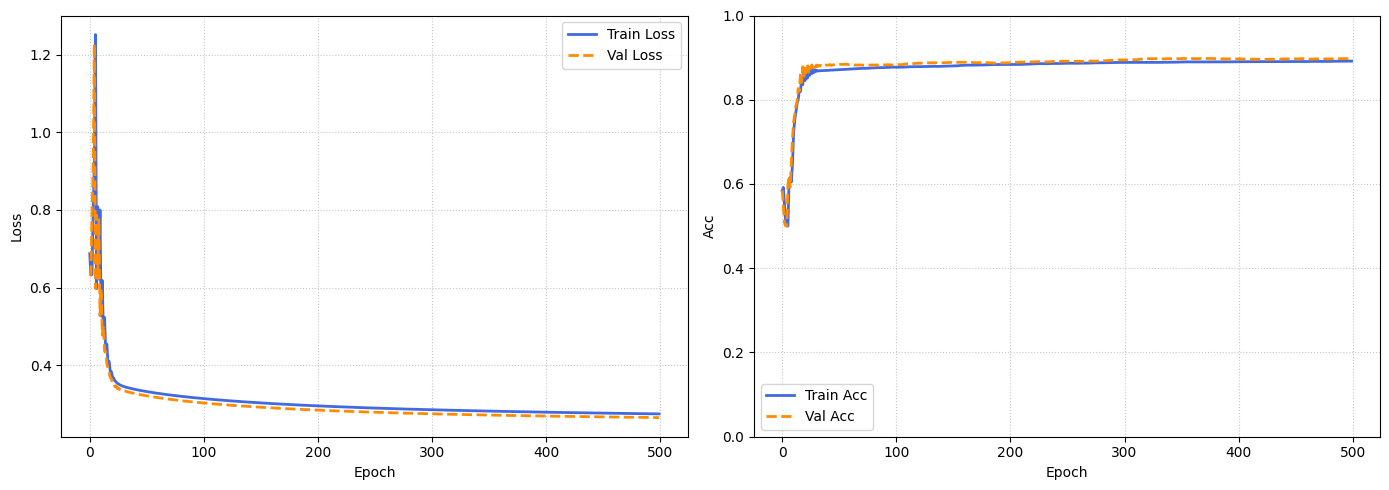

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax[0].plot(train_losses, label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(val_losses, label="Val Loss", color="darkorange", linewidth=2, linestyle="--")
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.7)

ax[1].plot(train_accs, label="Train Acc", color="royalblue", linewidth=2)
ax[1].plot(val_accs, label="Val Acc", color="darkorange", linewidth=2, linestyle="--")
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Acc')
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.7)
ax[1].set_ylim(0, 1)


fig.tight_layout()

plt.show()

Explain:

1. why logistic regression is suitable for binary classification,
2. why sigmoid is used,
3. why the derivative simplifies to $\frac{\partial L}{\partial z} = \hat{y} - y$,
4. why we can implement gradient descent here without autograd.

1. 
Klasyczna regresja liniowa przewiduje wartości ciągłe z nieograniczonego zakresu, co jest problematyczne przy klasyfikacji, gdzie oczekujemy prawdopodobieństwa przynależności do danej grupy. Zastosowanie funkcji logistycznej wynik modelu liniowego do przedziału $(0, 1)$. 

2. 
Funkcja logistyczna:
* jest to "ładna", gładka funkcja $\infty$-wiele razy różniczkowalna, bijekcja $\mathbb{R}$ w $(0, 1)$, $\sigma(0)=0.5$, naturalny wybór dla dystrybuanty
* jest coś takiego jak klasa GLM, tam funkcja logistyczna jest kanonczimym wyborem.

3. 
Liczyłem to wyżej.

4. 
Model regresji logistycznej to w gruncie rzeczy pojedyncza "warstwa". Z tego powodu nie generuje on głębokiego, skomplikowanego grafu obliczeniowego. Na wszystkie pochodne mamy proste analistyczne wzory.

# Zad2

In [46]:
X_batch = X_train[:64]
y_batch = y_train[:64]

W_init = torch.randn((d, 1)) * 0.01
b_init = torch.zeros((1,))

W_auto = W_init.clone().requires_grad_(True)
b_auto = b_init.clone().requires_grad_(True)

y_pred_auto = forward(X_batch, W_auto, b_auto)
loss_auto = BCE(y_batch, y_pred_auto)

loss_auto.backward()

grad_W_auto = W_auto.grad
grad_b_auto = b_auto.grad

y_pred_man = forward(X_batch, W_init, b_init)
loss_man = BCE(y_batch, y_pred_man)

grad_W_man, grad_b_man = get_gradients(X_batch, y_batch, y_pred_man)

diff_W = torch.norm(grad_W_man - grad_W_auto).item()
diff_b = torch.norm(grad_b_man - grad_b_auto).item()

print(f"Norma L2 różnicy dla W: {diff_W:.10f}")
print(f"Norma L2 różnicy dla b: {diff_b:.10f}")

Norma L2 różnicy dla W: 0.0000000474
Norma L2 różnicy dla b: 0.0000000075


Wyniki okazuja, że nie ma znacznego błędu w obliczeń.

Discuss:

1. why the two gradients should match,
2. possible reasons for small numerical differences,
3. why checking gradients is useful when implementing models from scratch.


1. Obliczamy pochdna tej samej funkcji, tego właśnie oczekujemy od funkcji bibliotecznych, ale też żeby było tam mało błędów numerycznych.

2. Autograd jest mocno zaoptymalizowany, ale nie idalny, konsturkacj grafu obliczeń i róznie obliczenia nie musza np: być wykonane w odpowiedniej kolejności.

3. Jest to odpowiedni sanity check, nie chcemy zeby blędy pojawiały się podczas liczenia gradientu to niszczy to wszelkie perspektywy modelu do uczenia się.

# Zad3

In [47]:
class SimpleMLP:
    def __init__(self, in_dim, hidden_dim, out_dim):
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim

        self.W_1 = (torch.randn((hidden_dim, in_dim)) * 0.01).requires_grad_(True)
        self.b_1 = torch.zeros((hidden_dim,)).requires_grad_(True)

        self.W_2 = (torch.randn((out_dim, hidden_dim)) * 0.01).requires_grad_(True)
        self.b_2 = torch.zeros((out_dim,)).requires_grad_(True)

        self.g_1 = torch.tanh
        self.g_2 = torch.sigmoid
    
    def forward(self, x):
        z1 = x @ self.W_1.T + self.b_1
        a1 = self.g_1(z1)
        
        z2 = a1 @ self.W_2.T + self.b_2
        y_pred = self.g_2(z2)
    
        return y_pred

1. Why an MLP can model more complex decision boundaries than logistic regression?
    * Regresja logistyczna to model liniowy, dodając jedną warste ukryta robimy z naszego modelu liniowego model nieliniowy, co potencjalnie ma pozwolic na wykyrywanie dużo bardzije skomplikowanych granic decyzyjnych

2. The role of the hidden activation function?
    * To właśnie funkcje akywacji wporwadzają nieliniowości w modelu.

3. Why we still need a sigmoid in the output layer?
    * Koniec końców rozwiązujemy to samo zadanie co wcześniej, nasz cel jest ten sam - wyznaczyć prawdopodobieństwa, a tak jak wcześniejszych zadaniach opisywalismy sigmoid się do tego nadaje.

In [48]:
def train_model(model, X_train, y_train, X_val, y_val, epochs, lr, loss_fn):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        train_pred = model.forward(X_train)
        y_train_class = (train_pred >= 0.5).float()
        
        train_loss = loss_fn(y_train, train_pred)
        train_loss.backward()

        train_acc = (y_train == y_train_class).float().mean()

        with torch.no_grad():
            model.W_1 -= lr * model.W_1.grad
            model.b_1 -= lr * model.b_1.grad

            model.W_2 -= lr * model.W_2.grad
            model.b_2 -= lr * model.b_2.grad

            model.W_1.grad.zero_()
            model.b_1.grad.zero_()
            model.W_2.grad.zero_()
            model.b_2.grad.zero_()
        
        with torch.no_grad():
            val_pred = model.forward(X_val)
            y_val_class = (val_pred >= 0.5).float()

            val_loss = loss_fn(y_val, y_val_class)
            val_acc = (y_val == y_val_class).float().mean()
        
        train_losses.append(train_loss.item())
        train_accs.append(train_acc.item())
        val_losses.append(val_loss.item())
        val_accs.append(val_acc.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1:3d}/{epochs}] | "
                  f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")
            
    return train_losses, val_losses, train_accs, val_accs

In [49]:
IN_DIM = 784
HIDDEN_DIM = 128
OUT_DIM = 1
EPOCHS = 500
LR = 0.1

mlp_model = SimpleMLP(IN_DIM, HIDDEN_DIM, OUT_DIM)

train_losses, val_losses, train_accs, val_accs = train_model(
    model=mlp_model, 
    X_train=X_train, y_train=y_train, 
    X_val=X_val, y_val=y_val, 
    epochs=EPOCHS, 
    lr=LR, 
    loss_fn=BCE 
)

Epoch [ 10/500] | Train Loss: 0.6556 | Train Acc: 0.6079 | Val Loss: 6.8709 | Val Acc: 0.6270
Epoch [ 20/500] | Train Loss: 0.5734 | Train Acc: 0.8176 | Val Loss: 3.1039 | Val Acc: 0.8315
Epoch [ 30/500] | Train Loss: 0.4512 | Train Acc: 0.8708 | Val Loss: 2.1368 | Val Acc: 0.8840
Epoch [ 40/500] | Train Loss: 0.3797 | Train Acc: 0.8707 | Val Loss: 2.1552 | Val Acc: 0.8830
Epoch [ 50/500] | Train Loss: 0.3516 | Train Acc: 0.8708 | Val Loss: 2.1921 | Val Acc: 0.8810
Epoch [ 60/500] | Train Loss: 0.3388 | Train Acc: 0.8712 | Val Loss: 2.1736 | Val Acc: 0.8820
Epoch [ 70/500] | Train Loss: 0.3309 | Train Acc: 0.8711 | Val Loss: 2.1644 | Val Acc: 0.8825
Epoch [ 80/500] | Train Loss: 0.3249 | Train Acc: 0.8721 | Val Loss: 2.1552 | Val Acc: 0.8830
Epoch [ 90/500] | Train Loss: 0.3199 | Train Acc: 0.8738 | Val Loss: 2.1276 | Val Acc: 0.8845
Epoch [100/500] | Train Loss: 0.3153 | Train Acc: 0.8746 | Val Loss: 2.1184 | Val Acc: 0.8850
Epoch [110/500] | Train Loss: 0.3111 | Train Acc: 0.8752 | V

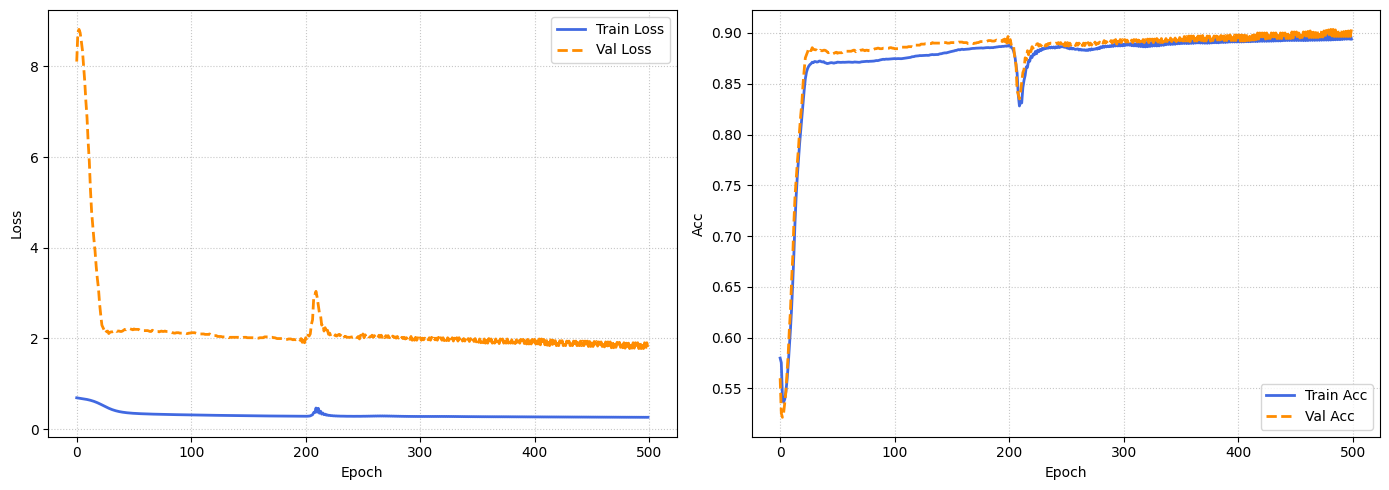

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax[0].plot(train_losses, label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(val_losses, label="Val Loss", color="darkorange", linewidth=2, linestyle="--")
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.7)

ax[1].plot(train_accs, label="Train Acc", color="royalblue", linewidth=2)
ax[1].plot(val_accs, label="Val Acc", color="darkorange", linewidth=2, linestyle="--")
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Acc')
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.7)
# ax[1].set_ylim(0, 1)


fig.tight_layout()

plt.show()

In [51]:
class MLP:
    def __init__(self, dims, act_fns):
        self.dims = dims
        self.W = []
        self.b = []
        self.act_fns = act_fns

        for (dim_in, dim_out) in zip(dims[:-1], dims[1:]):
            self.W.append((torch.randn((dim_out, dim_in)) * 0.01).requires_grad_(True))
            self.b.append(torch.zeros((dim_out,)).requires_grad_(True))

    def forward(self, x):
        for i in range(len(self.W)):
            z = x @ self.W[i].T + self.b[i]
            x = self.act_fns[i](z)
        return x
    
    def train(self, X_train, y_train, X_val, y_val, epochs, lr, loss_fn):
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(epochs):
            train_pred = self.forward(X_train)
            y_train_class = (train_pred >= 0.5).float()
            
            train_loss = loss_fn(y_train, train_pred)
            train_loss.backward()

            train_acc = (y_train == y_train_class).float().mean().item()

            with torch.no_grad():
                for i in range(len(self.W)):
                    self.W[i] -= lr * self.W[i].grad
                    self.b[i] -= lr * self.b[i].grad
                    
                    self.W[i].grad.zero_()
                    self.b[i].grad.zero_()
            
            with torch.no_grad():
                val_pred = self.forward(X_val)
                y_val_class = (val_pred >= 0.5).float()

                val_loss = loss_fn(y_val, val_pred)
                val_acc = (y_val == y_val_class).float().mean().item()
            
            train_losses.append(train_loss.item())
            train_accs.append(train_acc)
            val_losses.append(val_loss.item())
            val_accs.append(val_acc)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch + 1:3d}/{epochs}] | "
                      f"Train Loss: {train_loss.item():.4f} | Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}")
                
        return train_losses, val_losses, train_accs, val_accs

In [52]:
def plot_model(train_losses, val_losses, train_accs, val_accs):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    ax[0].plot(train_losses, label="Train Loss", color="royalblue", linewidth=2)
    ax[0].plot(val_losses, label="Val Loss", color="darkorange", linewidth=2, linestyle="--")
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, linestyle=':', alpha=0.7)

    ax[1].plot(train_accs, label="Train Acc", color="royalblue", linewidth=2)
    ax[1].plot(val_accs, label="Val Acc", color="darkorange", linewidth=2, linestyle="--")
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Acc')
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.7)
    ax[1].set_ylim(0, 1)


    fig.tight_layout()

    plt.show()


In [53]:
dims = [784, 64, 32, 1]
act_fns = [torch.tanh, torch.tanh, torch.sigmoid]

model = MLP(dims, act_fns)

train_losses, val_losses, train_accs, val_accs = model.train(
    X_train, y_train, X_val, y_val, epochs=500, lr=0.1, loss_fn=BCE
)

Epoch [ 10/500] | Train Loss: 0.6931 | Train Acc: 0.5303 | Val Loss: 0.6931 | Val Acc: 0.5255
Epoch [ 20/500] | Train Loss: 0.6930 | Train Acc: 0.5542 | Val Loss: 0.6930 | Val Acc: 0.5495
Epoch [ 30/500] | Train Loss: 0.6929 | Train Acc: 0.5834 | Val Loss: 0.6929 | Val Acc: 0.5755
Epoch [ 40/500] | Train Loss: 0.6928 | Train Acc: 0.6059 | Val Loss: 0.6928 | Val Acc: 0.5995
Epoch [ 50/500] | Train Loss: 0.6926 | Train Acc: 0.6225 | Val Loss: 0.6926 | Val Acc: 0.6170
Epoch [ 60/500] | Train Loss: 0.6923 | Train Acc: 0.6339 | Val Loss: 0.6923 | Val Acc: 0.6300
Epoch [ 70/500] | Train Loss: 0.6919 | Train Acc: 0.6408 | Val Loss: 0.6919 | Val Acc: 0.6355
Epoch [ 80/500] | Train Loss: 0.6912 | Train Acc: 0.6446 | Val Loss: 0.6912 | Val Acc: 0.6380
Epoch [ 90/500] | Train Loss: 0.6902 | Train Acc: 0.6439 | Val Loss: 0.6901 | Val Acc: 0.6390
Epoch [100/500] | Train Loss: 0.6883 | Train Acc: 0.6432 | Val Loss: 0.6881 | Val Acc: 0.6390
Epoch [110/500] | Train Loss: 0.6850 | Train Acc: 0.6432 | V

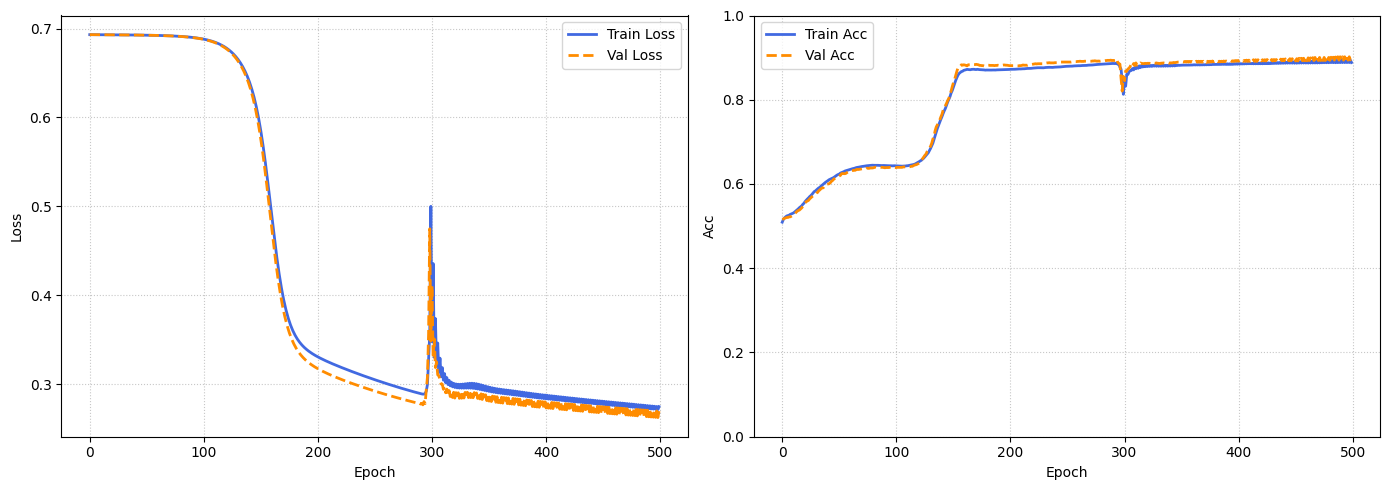

In [54]:
plot_model(train_losses, val_losses, train_accs, val_accs)

Ewidentnie w moim przypadku najprostrzym model poradził sobie najlepiej podczas treningu.
Wszystkie doszły do tego samego celu, do tego samego poziomu acc na train i val.

Ale regresja logistyczna ma najstabliczniejszy, najszybszy trening a w dodatku wykorzystuje najmniej zasobów obliczeniowych. Pozostałe modele nie są odpowiednio stabline, w trakcie treningu następują spadki precyzji.